In [19]:
import numpy as np
import lib_debug

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


--- Strategy Selected: LCB ---
--- Starting Optimization Loop (30 iterations) ---
Iter  | Best y     | New y      | New x (approx)
--------------------------------------------------
1     | -0.825757   | 0.479466   | [1.00]
2     | -0.915267   | -0.915267   | [0.71]
3     | -0.915267   | -0.780427   | [0.72]
4     | -0.915267   | -0.825823   | [0.71]
5     | -0.915267   | -0.871160   | [0.71]
6     | -0.915267   | -0.817719   | [0.72]
7     | -0.915267   | -0.850230   | [0.70]
8     | -0.936460   | -0.936460   | [0.70]
9     | -0.948556   | -0.948556   | [0.70]
10    | -0.948556   | -0.874322   | [0.70]
11    | -0.948556   | -0.873707   | [0.70]
12    | -0.948556   | -0.905337   | [0.70]
13    | -0.964556   | -0.964556   | [0.70]
14    | -0.964556   | -0.828538   | [0.69]
15    | -0.964556   | -0.868039   | [0.70]
16    | -0.964556   | -0.795604   | [0.70]
17    | -0.964556   | -0.860298   | [0.70]
18    | -0.964556   | -0.946016   | [0.70]
19    | -0.964556   | -0.814783   | [0.70]
20

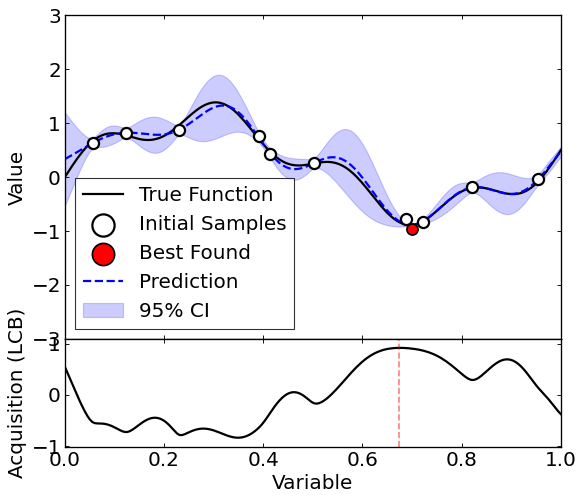

--------------------------------------------------
Optimization Finished using LCB.
Global Best Found: y = -0.964556


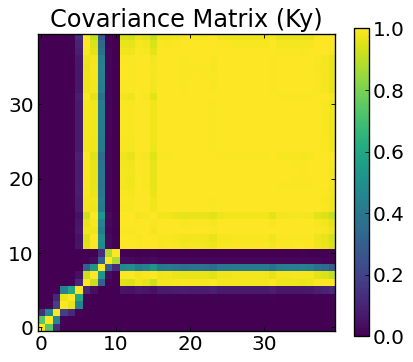

In [27]:
# -------------------- 1. Setup & Aliasing --------------------
kernel = lib_debug.rbf_kernel

# -------------------- 2. Settings --------------------
# Hyperparameters
gamma = 65.0
noise_std = 0.05
noise_var = noise_std ** 2

# Domain settings
dims = 1
lower_bounds = [0.0]
upper_bounds = [1.0]

# Optimization Loop Settings
n_init = 10
n_iter = 30
xi = 0.01

# Grid for plotting ONLY (No longer used for search loop)
X_grid = np.linspace(0, 1, 200)[:, None]

# --- Acquisition Function Selection ---
STRATEGY = "LCB"  # Options: "EI" or "LCB"

if STRATEGY == "EI":
    acq_func = lib_debug.expected_improvement
    acq_params = {'xi': 0.01}
elif STRATEGY == "LCB":
    acq_func = lib_debug.lower_confidence_bound
    acq_params = {'kappa': 2.0}
else:
    raise ValueError("Unknown strategy")

print(f"--- Strategy Selected: {STRATEGY} ---")

# -------------------- 3. Initialization --------------------
# Generate samples and observations
X_train = lib_debug.LHSsampler(dims, n_init, lower_bounds, upper_bounds)
X_train = X_train[np.argsort(X_train[:, 0])]
y_train = lib_debug.test_1D(X_train).reshape(-1, 1) + np.random.normal(0, noise_std, (len(X_train), 1))

# Keep copy for plotting
X_init_plot = X_train.copy()
y_init_plot = y_train.copy()

# -------------------- 4. Bayesian Optimization Loop --------------------
print(f"--- Starting Optimization Loop ({n_iter} iterations) ---")
print(f"{'Iter':<5} | {'Best y':<10} | {'New y':<10} | {'New x (approx)'}")
print("-" * 50)

for i in range(n_iter):
    
    # 1. Fit GP (Calculate Ky_inv)
    Ky_inv = lib_debug.fit_gp(kernel, X_train, gamma, noise_var)

    # 2. Find Next Point (Continuous Optimization instead of Grid Search)
    x_new, _ = lib_debug.optimize_acquisition(
        kernel, 
        acq_func, 
        X_train, y_train, Ky_inv, gamma, 
        lower_bounds, upper_bounds, acq_params
    )
    
    # 3. Evaluate True Function
    # x_new comes out as (dims,), need reshape for evaluation
    y_new = lib_debug.test_1D(x_new.reshape(1, -1)) + np.random.normal(0, noise_std, (1, 1))

    # 4. Update Data
    X_train = np.vstack([X_train, x_new])
    y_train = np.vstack([y_train, y_new])
    
    # Log
    current_best = np.min(y_train)
    print(f"{i+1:<5} | {current_best:.6f}   | {y_new.item():.6f}   | [{x_new[0]:.2f}]")


# -------------------- 5. Final Calculation & Visualization --------------------
# Re-fit GP with all data
Ky_inv = lib_debug.fit_gp(kernel, X_train, gamma, noise_var)

# Get predictions and acquisition values for plotting
# (Here we still use X_grid to draw the curves)
mu_list = []
sigma_list = []
acq_final_list = []

for x in X_grid:
    m, s = lib_debug.get_posterior(kernel, x, X_train, y_train, Ky_inv, gamma)
    mu_list.append(m)
    sigma_list.append(s)
    acq_final_list.append(acq_func(kernel, x, X_train, y_train, Ky_inv, gamma, **acq_params))

mu_post = np.array(mu_list)
s_post = np.array(sigma_list)
acq_final = np.array(acq_final_list)

# Identify Best Point
best_idx_final = np.argmin(y_train)
best_x = X_train[best_idx_final]
best_y = y_train[best_idx_final]

# Visualization
lib_debug.plot_gp_results(
    X_grid=X_grid,
    true_func=lib_debug.test_1D,
    X_init=X_init_plot,
    y_init=y_init_plot,
    best_x=best_x,
    best_y=best_y,
    mu=mu_post,
    sigma=s_post,
    acq_values=acq_final,
    strategy_name=STRATEGY
)

print("-" * 50)
print(f"Optimization Finished using {STRATEGY}.")
print(f"Global Best Found: y = {y_train[best_idx_final].item():.6f}")

# Final Covariance Plot
K_final = kernel(X_train, X_train, gamma)
lib_debug.plot_covariance_matrix(K_final)

--- Strategy Selected: LCB ---
--- Starting Optimization Loop (100 iterations) ---
Iter  | Best y     | New y      | Gamma    | New x (approx)
---------------------------------------------------------------------------
1     | 1.019732   | 1.019732   | 1.4717   | [0.08, -0.14]
2     | 1.019732   | 1.520781   | 1.4619   | [-0.01, -0.22]
3     | 1.019732   | 2.259426   | 1.6212   | [0.30, 0.09]
4     | 1.019732   | 6.447467   | 2.2054   | [2.00, 0.34]
5     | 1.019732   | 5.847804   | 2.1657   | [-1.11, -2.00]
6     | 1.019732   | 3.037436   | 2.0914   | [0.28, -0.29]
7     | 0.304522   | 0.304522   | 2.2819   | [-0.02, 0.06]
8     | 0.114547   | 0.114547   | 2.2791   | [-0.02, 0.02]
9     | 0.114547   | 6.782619   | 3.3178   | [-2.00, 0.53]
10    | 0.114547   | 0.940537   | 3.2334   | [-0.15, -0.03]
11    | 0.114547   | 5.795352   | 4.8430   | [1.11, 2.00]
12    | 0.114547   | 6.593599   | 4.7637   | [-2.00, -2.00]
13    | 0.114547   | 6.319414   | 4.6869   | [-0.31, -2.00]
14    | 0.11

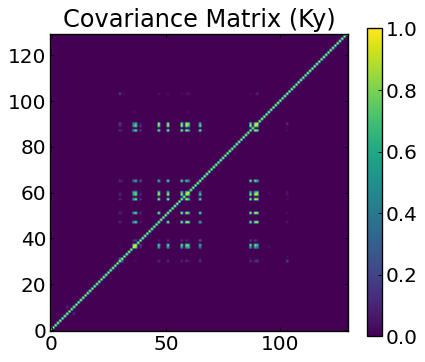

In [29]:
import numpy as np
from scipy.optimize import minimize
import lib_debug

# -------------------- 1. Setup & Aliasing --------------------
kernel = lib_debug.rbf_kernel

# -------------------- 2. Settings --------------------
dims = 2
lower_bounds = [-2.0, -2.0]
upper_bounds = [2.0, 2.0]

# Initial Gamma
current_gamma = 1.0
noise_std = 0.0
noise_var = noise_std ** 2

n_init = 30
n_iter = 100

# Strategy Selection
STRATEGY = "EI" 
if STRATEGY == "EI":
    acq_func = lib_debug.expected_improvement
    acq_params = {'xi': 0.01}
elif STRATEGY == "LCB":
    acq_func = lib_debug.lower_confidence_bound
    acq_params = {'kappa': 2.0}
else:
    raise ValueError("Unknown strategy")

print(f"--- Strategy Selected: {STRATEGY} ---")

# -------------------- 3. Initialization --------------------
X_train = lib_debug.LHSsampler(dims, n_init, lower_bounds, upper_bounds)
y_train = lib_debug.ackley_2d(X_train).reshape(-1, 1)

# NOTE: No Grid creation here anymore! (We use continuous optimization)

# -------------------- 4. Bayesian Optimization Loop --------------------
print(f"--- Starting Optimization Loop ({n_iter} iterations) ---")
print(f"{'Iter':<5} | {'Best y':<10} | {'New y':<10} | {'Gamma':<8} | {'New x (approx)'}")
print("-" * 75)

for i in range(n_iter):

    # --- Step A: Optimize Hyperparameters (Gamma) ---
    res_hyp = minimize(
        lib_debug.negative_log_marginal_likelihood, 
        x0=[current_gamma], 
        args=(X_train, y_train, noise_var),
        bounds=[(0.1, 100.0)], 
        method='L-BFGS-B'
    )
    if res_hyp.success:
        current_gamma = res_hyp.x[0]

    # --- Step B: Fit GP (Calculate Ky_inv) ---
    Ky_inv = lib_debug.fit_gp(kernel, X_train, current_gamma, noise_var)

    # --- Step C & D: Optimize Acquisition Function (Find Next Point) ---
    # Instead of Grid Search, we use continuous optimization (L-BFGS-B)
    x_new, _ = lib_debug.optimize_acquisition(
        kernel, 
        acq_func, 
        X_train, y_train, Ky_inv, current_gamma, 
        lower_bounds, upper_bounds, acq_params
    )
    
    # --- Step E: Evaluate True Function ---
    y_new = lib_debug.ackley_2d(x_new.reshape(1, -1))

    # --- Step F: Update Data ---
    X_train = np.vstack([X_train, x_new])
    y_train = np.vstack([y_train, y_new])

    # Log
    current_best = np.min(y_train)
    print(f"{i+1:<5} | {current_best:.6f}   | {y_new.item():.6f}   | {current_gamma:.4f}   | [{x_new[0]:.2f}, {x_new[1]:.2f}]")

# -------------------- 5. Final Result & Visualization --------------------
best_idx_final = np.argmin(y_train)
print("-" * 75)
print(f"Optimization Finished.")
print(f"Global Best Found: y = {y_train[best_idx_final].item():.6f}")
print(f"At location: x = {X_train[best_idx_final]}")

# Final Covariance Plot
K_final = kernel(X_train, X_train, current_gamma)
lib_debug.plot_covariance_matrix(K_final)